# 💳 Credit Card Fraud Detection — Machine Learning Project
### Samatrix Consulting Pvt Ltd | ML Course Project

---

**Domain:** Finance  
**Objective:** Predict whether a credit card transaction is **fraudulent** or **legitimate**  
**Dataset:** European cardholders — 2-day transactions (September 2013)  
- 284,807 total transactions | 492 fraud cases (0.17%)  
- Features V1–V28: PCA-anonymized (privacy reasons) | `Time`, `Amount`, `Class` are original  
- `Class`: 0 = Not Fraud, 1 = Fraud

---

## Project Steps
1. Import Libraries & Load Data  
2. Understanding Data (EDA — Shape, Types, Nulls, Stats)  
3. Response Variable Analysis  
4. Data Visualization  
5. Data Cleaning  
6. Train / Test Split  
7. Data Modeling (7 Algorithms)  
8. Model Selection  
9. Confusion Matrix & Performance Metrics  
10. Result Summary  


## Step 1 — Import Libraries & Load Data

In [1]:
# Install dependencies (needed for Google Colab)
# Uncomment the line below if running on Colab
# !pip install scikit-learn pandas numpy matplotlib seaborn -q


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import set_option
from pandas.plotting import scatter_matrix

# Sklearn — Preprocessing & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# Sklearn — Linear Models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Sklearn — Non-Linear Models
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✓")


All libraries imported successfully ✓


In [10]:
from google.colab import files
uploaded = files.upload()

import io
fraud_data = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print(f"Shape: {fraud_data.shape[0]:,} rows × {fraud_data.shape[1]} columns")

Saving creditcard_fraud_detection.csv to creditcard_fraud_detection.csv
Shape: 284,807 rows × 31 columns


---
## Step 2 — Understanding Data

We follow these sub-steps:
- View raw data
- Dimensions
- Data types & null check
- Statistical summary


In [11]:
# 2.1 View raw data
set_option('display.width', 100)
fraud_data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
# 2.2 Dimensions
print(f"Rows    : {fraud_data.shape[0]:,}")
print(f"Columns : {fraud_data.shape[1]}")


Rows    : 284,807
Columns : 31


In [13]:
# 2.3 Data Types
fraud_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [14]:
# 2.4 Null / Missing Values
null_counts = fraud_data.isnull().sum()
print("Null values per column:")
print(null_counts)
print(f"\nTotal null values: {null_counts.sum()}")
print("\n✓ Dataset has NO missing values — no imputation needed.")


Null values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total null values: 0

✓ Dataset has NO missing values — no imputation needed.


In [15]:
# 2.5 Statistical Summary
set_option('display.precision', 2)
fraud_data.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,...,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,2.85e+05,284807.00,2.85e+05
mean,94813.86,1.76e-12,-8.25e-13,-9.65e-13,8.32e-13,1.65e-13,4.25e-13,-3.05e-13,8.78e-14,-1.18e-12,...,-3.41e-13,-5.72e-13,-9.73e-13,1.46e-12,-6.99e-13,-5.62e-13,3.33e-12,-3.52e-12,88.35,1.73e-03
std,47488.15,1.96e+00,1.65e+00,1.52e+00,1.42e+00,1.38e+00,1.33e+00,1.24e+00,1.19e+00,1.10e+00,...,7.35e-01,7.26e-01,6.24e-01,6.06e-01,5.21e-01,4.82e-01,4.04e-01,3.30e-01,250.12,4.15e-02
min,0.00,-5.64e+01,-7.27e+01,-4.83e+01,-5.68e+00,-1.14e+02,-2.62e+01,-4.36e+01,-7.32e+01,-1.34e+01,...,-3.48e+01,-1.09e+01,-4.48e+01,-2.84e+00,-1.03e+01,-2.60e+00,-2.26e+01,-1.54e+01,0.00,0.00e+00
25%,54201.50,-9.20e-01,-5.99e-01,-8.90e-01,-8.49e-01,-6.92e-01,-7.68e-01,-5.54e-01,-2.09e-01,-6.43e-01,...,-2.28e-01,-5.42e-01,-1.62e-01,-3.55e-01,-3.17e-01,-3.27e-01,-7.08e-02,-5.30e-02,5.60,0.00e+00
50%,84692.00,1.81e-02,6.55e-02,1.80e-01,-1.98e-02,-5.43e-02,-2.74e-01,4.01e-02,2.24e-02,-5.14e-02,...,-2.95e-02,6.78e-03,-1.12e-02,4.10e-02,1.66e-02,-5.21e-02,1.34e-03,1.12e-02,22.00,0.00e+00
75%,139320.50,1.32e+00,8.04e-01,1.03e+00,7.43e-01,6.12e-01,3.99e-01,5.70e-01,3.27e-01,5.97e-01,...,1.86e-01,5.29e-01,1.48e-01,4.40e-01,3.51e-01,2.41e-01,9.10e-02,7.83e-02,77.16,0.00e+00
max,172792.00,2.45e+00,2.21e+01,9.38e+00,1.69e+01,3.48e+01,7.33e+01,1.21e+02,2.00e+01,1.56e+01,...,2.72e+01,1.05e+01,2.25e+01,4.58e+00,7.52e+00,3.52e+00,3.16e+01,3.38e+01,25691.16,1.00e+00


**Observation:**  
Variables V1–V28 are already scaled (PCA-transformed) — their mean ≈ 0 and std ≈ 1.  
`Time` and `Amount` are on their original scale and may benefit from normalization for distance-based models.  
No data cleaning required for this dataset as stated in the course material.


---
## Step 3 — Response Variable Analysis (Class Distribution)


In [16]:
# Class distribution
class_names = {0: 'Not Fraud', 1: 'Fraud'}
class_counts = fraud_data['Class'].value_counts().rename(index=class_names)
print(class_counts)
fraud_pct = (class_counts['Fraud'] / class_counts.sum()) * 100
print(f"\nFraud %: {fraud_pct:.4f}%")
print("\n⚠  HIGHLY IMBALANCED DATASET!")
print("   Naive 'always predict Not Fraud' baseline accuracy ≈ 99.83%")
print("   This makes raw Accuracy a misleading metric — use Precision, Recall, F1.")


Class
Not Fraud    284315
Fraud           492
Name: count, dtype: int64

Fraud %: 0.1727%

⚠  HIGHLY IMBALANCED DATASET!
   Naive 'always predict Not Fraud' baseline accuracy ≈ 99.83%
   This makes raw Accuracy a misleading metric — use Precision, Recall, F1.


---
## Step 4 — Data Visualization


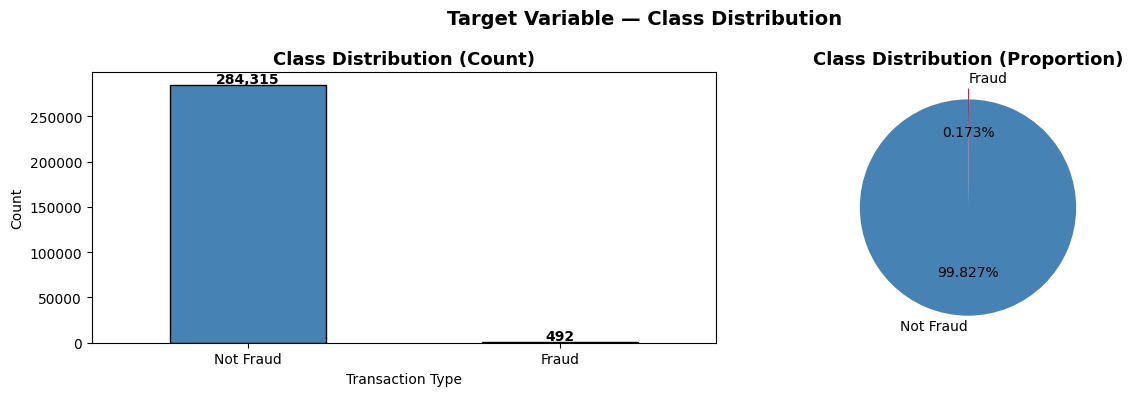

In [17]:
# ── Plot 1: Class Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts.plot(kind='bar', ax=axes[0],
                  color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values,
            labels=class_counts.index,
            autopct='%1.3f%%',
            colors=['steelblue', 'crimson'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Fraud   — Mean: $122.21  | Median: $9.25  | Max: $2125.87
Normal  — Mean: $88.29 | Median: $22.00 | Max: $25691.16


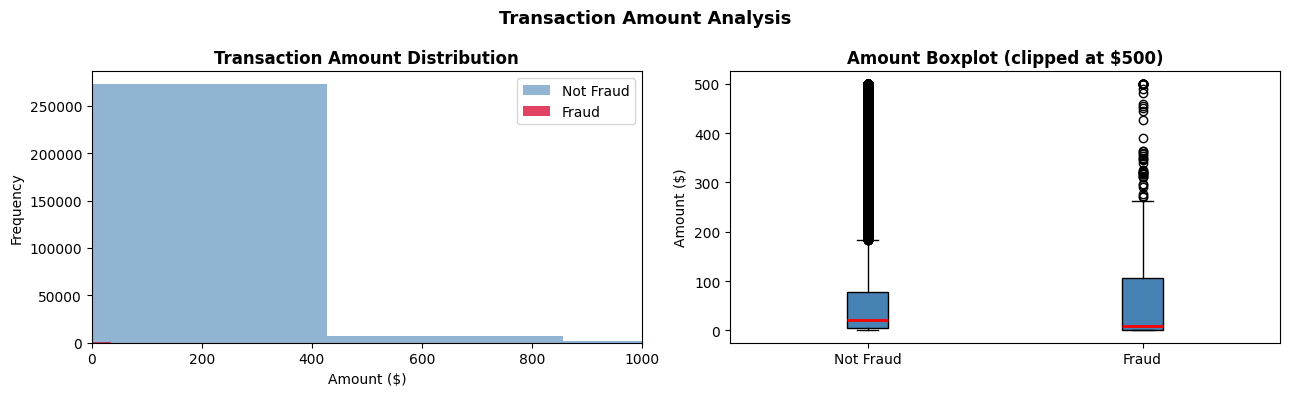

In [18]:
# ── Plot 2: Transaction Amount by Class ───────────────────────────────────
fraud_amounts  = fraud_data[fraud_data['Class'] == 1]['Amount']
normal_amounts = fraud_data[fraud_data['Class'] == 0]['Amount']

print(f"Fraud   — Mean: ${fraud_amounts.mean():.2f}  | Median: ${fraud_amounts.median():.2f}  | Max: ${fraud_amounts.max():.2f}")
print(f"Normal  — Mean: ${normal_amounts.mean():.2f} | Median: ${normal_amounts.median():.2f} | Max: ${normal_amounts.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(normal_amounts, bins=60, color='steelblue', alpha=0.6, label='Not Fraud')
axes[0].hist(fraud_amounts,  bins=60, color='crimson',   alpha=0.8, label='Fraud')
axes[0].set_xlim(0, 1000)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot([normal_amounts.clip(upper=500), fraud_amounts.clip(upper=500)],
                labels=['Not Fraud', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount Boxplot (clipped at $500)', fontweight='bold')
axes[1].set_ylabel('Amount ($)')

plt.suptitle('Transaction Amount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


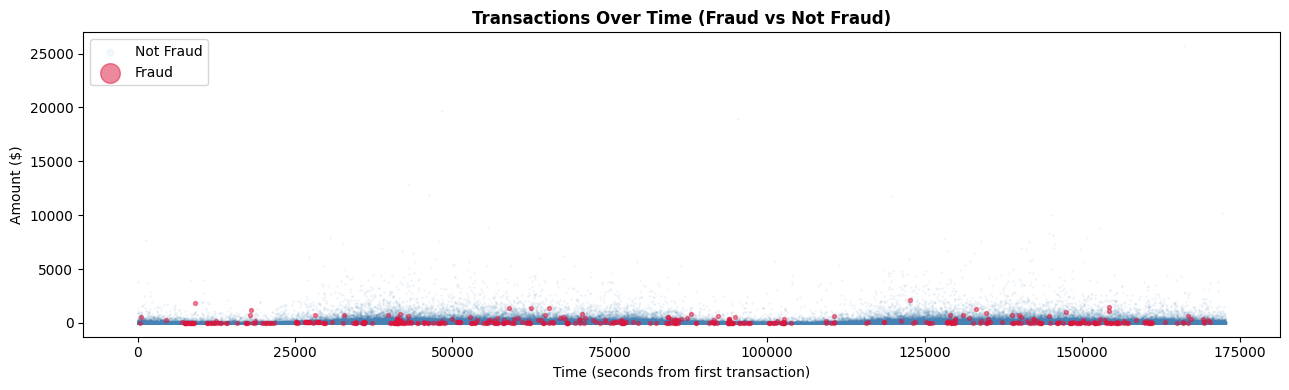

In [19]:
# ── Plot 3: Transactions Over Time ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(fraud_data[fraud_data['Class'] == 0]['Time'],
           fraud_data[fraud_data['Class'] == 0]['Amount'],
           alpha=0.05, color='steelblue', label='Not Fraud', s=1)
ax.scatter(fraud_data[fraud_data['Class'] == 1]['Time'],
           fraud_data[fraud_data['Class'] == 1]['Amount'],
           alpha=0.5,  color='crimson',   label='Fraud',     s=8)
ax.set_xlabel('Time (seconds from first transaction)')
ax.set_ylabel('Amount ($)')
ax.set_title('Transactions Over Time (Fraud vs Not Fraud)', fontweight='bold')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()


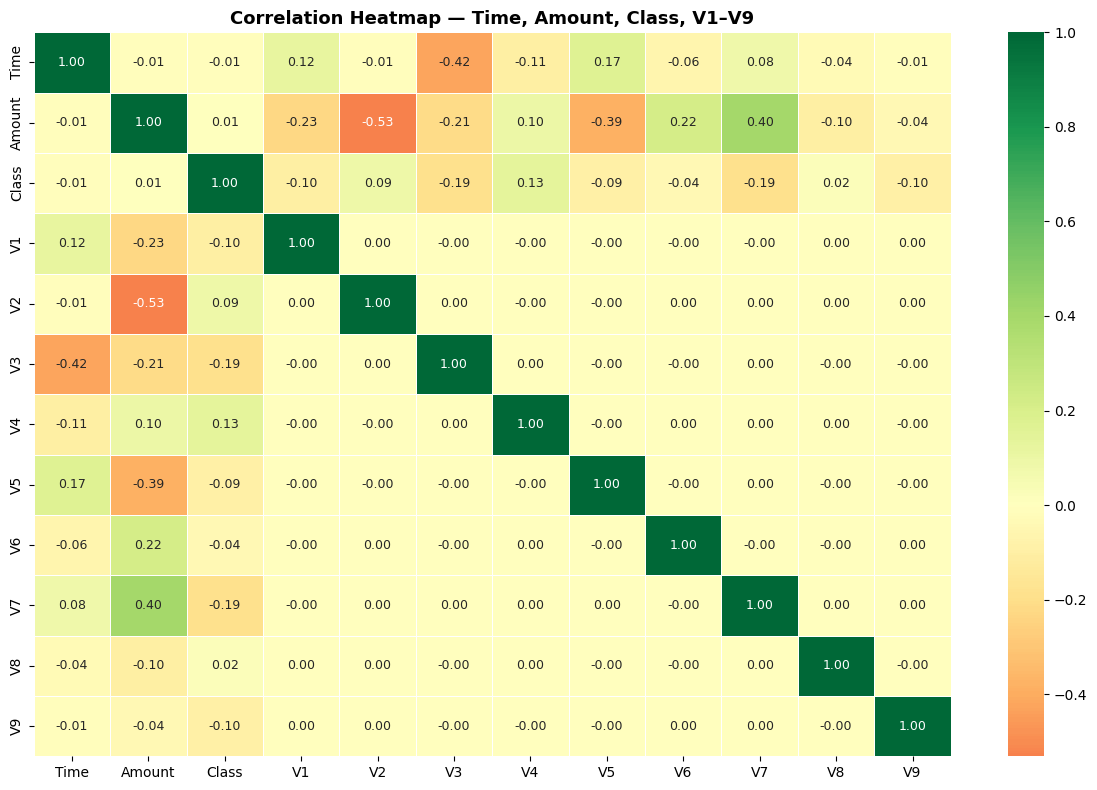

Note: Full scatterplot matrix skipped for V1-V28 as per course guidance
      (anonymized PCA features yield no interpretable insights).


In [20]:
# ── Plot 4: Correlation Heatmap (Time, Amount, Class, V1–V9) ──────────────
# Note: Since V1-V28 are anonymized PCA components, full scatter matrix
# gives no domain insights (as noted in the course slides).
# We show a heatmap of correlation instead.

corr_cols = ['Time', 'Amount', 'Class'] + [f'V{i}' for i in range(1, 10)]
corr_matrix = fraud_data[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap — Time, Amount, Class, V1–V9',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Note: Full scatterplot matrix skipped for V1-V28 as per course guidance")
print("      (anonymized PCA features yield no interpretable insights).")


---
## Step 5 — Data Cleaning

As confirmed by the statistical analysis and null value check:
- ✓ No missing/null values  
- ✓ No duplicate columns  
- ✓ V1–V28 already PCA-scaled — no normalization needed for these  
- ✓ Data cleaning and categorization **NOT required**

> *Note:* `Time` and `Amount` are unscaled. For distance-based models (KNN, SVM), standardizing them could improve performance — but the course baseline does not apply this step.


In [21]:
# Confirm no duplicates
print(f"Duplicate rows: {fraud_data.duplicated().sum()}")
print("Data is clean and ready for modeling ✓")


Duplicate rows: 1081
Data is clean and ready for modeling ✓


---
## Step 6 — Train / Test Split

- `Class` is the **output variable (y)**; all other columns are **input variables (X)**
- Split ratio: **2/3 train, 1/3 test** (as in the course)
- `stratify=y` — ensures the 0.17% fraud ratio is preserved in both sets
- `random_state=42` — reproducible results


In [22]:
# Separate features and target
y = fraud_data['Class']
X = fraud_data.drop(columns=['Class'])

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42,
    stratify=y
)

print(f"\nTraining set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"\nFraud in train : {y_train.sum()}  ({y_train.mean()*100:.4f}%)")
print(f"Fraud in test  : {y_test.sum()}   ({y_test.mean()*100:.4f}%)")
print("\nstratify=y preserved the fraud ratio in both splits ✓")


Features (X) shape : (284807, 30)
Target   (y) shape : (284807,)

Training set : 189,871 samples
Test set     : 94,936 samples

Fraud in train : 328  (0.1727%)
Fraud in test  : 164   (0.1727%)

stratify=y preserved the fraud ratio in both splits ✓


---
## Step 7 — Data Modeling

Evaluating **7 classification algorithms** — both Linear and Non-Linear:

| # | Algorithm | Type |
|---|---|---|
| 1 | Logistic Regression | Linear |
| 2 | Linear Discriminant Analysis | Linear |
| 3 | Gaussian Naive Bayes | Non-Linear |
| 4 | Decision Tree (CART) | Non-Linear |
| 5 | Random Forest | Non-Linear (Ensemble) |
| 6 | Support Vector Machine | Non-Linear |
| 7 | K-Nearest Neighbours | Non-Linear |


In [23]:
# ── 7.1 Logistic Regression ────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

logisreg = LogisticRegression(max_iter=1000)
logisreg.fit(X_train, y_train)
y_pred_lr = logisreg.predict(X_test)
acc_logisreg = round(accuracy_score(y_test, y_pred_lr) * 100, 2)
print(f"Accuracy of Logistic Regression model : {acc_logisreg}")


Accuracy of Logistic Regression model : 99.91


In [24]:
# ── 7.2 Linear Discriminant Analysis ───────────────────────────────────────
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_train, y_train)
y_pred_lda = model_lda.predict(X_test)
acc_lda = round(accuracy_score(y_test, y_pred_lda) * 100, 2)
print(f"Accuracy of Linear Discriminant Analysis Classifier: {acc_lda}")


Accuracy of Linear Discriminant Analysis Classifier: 99.93


In [25]:
# ── 7.3 Gaussian Naive Bayes ───────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB

model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)
y_pred_gnb = model_gnb.predict(X_test)
acc_ganb = round(accuracy_score(y_test, y_pred_gnb) * 100, 2)
print(f"Accuracy of Gaussian Naive Bayes : {acc_ganb}")


Accuracy of Gaussian Naive Bayes : 99.28


In [26]:
# ── 7.4 Decision Tree (CART) ───────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
acc_dtree = round(accuracy_score(y_test, y_pred_dt) * 100, 2)
print(f"Accuracy of Decision Tree Classifier : {acc_dtree}")


Accuracy of Decision Tree Classifier : 99.91


In [27]:
# ── 7.5 Random Forest ──────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
acc_rf = round(accuracy_score(y_test, y_pred_rf) * 100, 2)
print(f"Accuracy of Random Forest : {acc_rf}")


Accuracy of Random Forest : 99.95


In [28]:
# ── 7.6 Support Vector Machine ─────────────────────────────────────────────
from sklearn import svm

model_svm = svm.SVC(random_state=42)
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
acc_svc = round(accuracy_score(y_test, y_pred_svm) * 100, 2)
print(f"Accuracy of Support Vector Classifier: {acc_svc}")


Accuracy of Support Vector Classifier: 99.83


In [29]:
# ── 7.7 K-Nearest Neighbours (K=5 default) ─────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()   # default k=5
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
acc_knn = round(accuracy_score(y_test, y_pred_knn) * 100, 2)
print(f"Accuracy of KNN Classifier: {acc_knn}")


Accuracy of KNN Classifier: 99.83


---
## Step 8 — Model Selection


In [30]:
# Compile all scores into a DataFrame and sort
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Discriminant Analysis',
              'Naive Bayes', 'Decision Tree', 'Random Forest',
              'Support Vector Machines', 'K - Nearest Neighbors'],
    'Score': [acc_logisreg, acc_lda, acc_ganb, acc_dtree,
              acc_rf, acc_svc, acc_knn]
})

models_sorted = models.sort_values(by='Score', ascending=False).reset_index(drop=True)
print("Model Accuracy Rankings:")
print(models_sorted.to_string(index=False))


Model Accuracy Rankings:
                       Model  Score
               Random Forest  99.95
Linear Discriminant Analysis  99.93
         Logistic Regression  99.91
               Decision Tree  99.91
     Support Vector Machines  99.83
       K - Nearest Neighbors  99.83
                 Naive Bayes  99.28


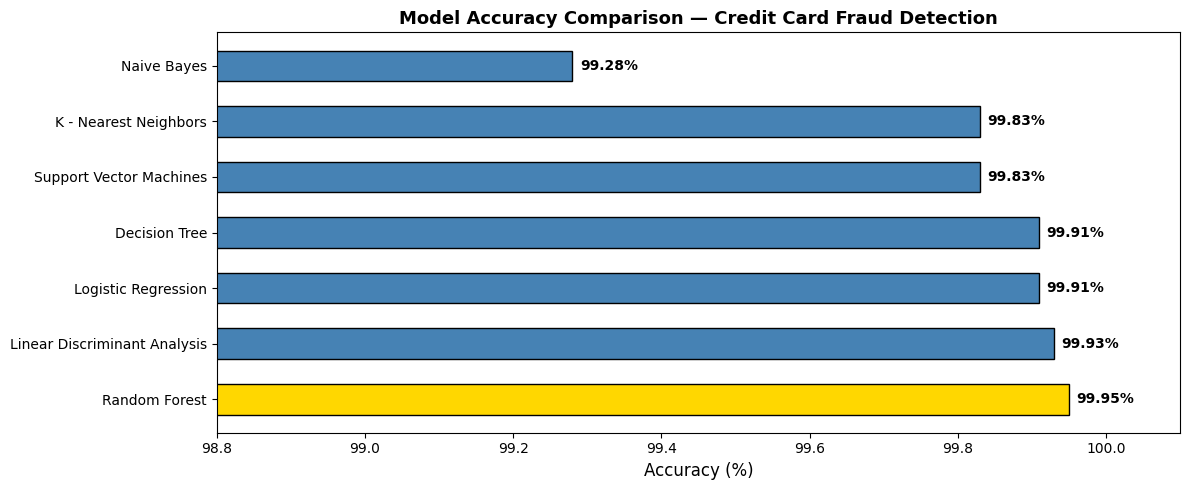


🏆 Best Model: Random Forest — Accuracy: 99.95%


In [31]:
# Bar chart — Model comparison
plt.figure(figsize=(12, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(models_sorted))]
bars = plt.barh(models_sorted['Model'], models_sorted['Score'],
                color=colors, edgecolor='black', height=0.55)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison — Credit Card Fraud Detection',
          fontsize=13, fontweight='bold')
plt.xlim(98.8, 100.1)

for bar, score in zip(bars, models_sorted['Score']):
    plt.text(score + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score}%', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

best_model = models_sorted.iloc[0]['Model']
best_score = models_sorted.iloc[0]['Score']
print(f"\n🏆 Best Model: {best_model} — Accuracy: {best_score}%")


---
## Step 9 — Confusion Matrix & Performance Metrics

**Best model: Random Forest** — analyzed using Confusion Matrix

| Term | Meaning |
|------|---------|
| **True Positive (TP)** | Predicted Fraud, Actually Fraud ✓ |
| **True Negative (TN)** | Predicted Not Fraud, Actually Not Fraud ✓ |
| **False Positive (FP)** | Predicted Fraud, Actually Not Fraud ✗ (false alarm) |
| **False Negative (FN)** | Predicted Not Fraud, Actually Fraud ✗ ⚠ **most dangerous!** |

**Formulas:**
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN) ← *most important for fraud detection*
- **Accuracy** = (TP + TN) / Total
- **F1-Score** = 2 × Precision × Recall / (Precision + Recall)


In [32]:
# Confusion Matrix — Random Forest (best model)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

print(f"\nTrue  Negatives (TN) — Correctly predicted Not Fraud : {TN:,}")
print(f"False Positives (FP) — False alarms                  : {FP}")
print(f"False Negatives (FN) — Missed Fraud ⚠                : {FN}")
print(f"True  Positives (TP) — Correctly caught Fraud         : {TP}")

precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f"\nAccuracy  : {acc_rf}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%   ← % of actual frauds caught")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"\n⚠  {FN} out of {TP+FN} fraud cases were MISSED (false negatives)")
print(f"   False-negative rate: {FN/(TP+FN)*100:.1f}%")


Confusion Matrix:
[[94766     6]
 [   38   126]]

True  Negatives (TN) — Correctly predicted Not Fraud : 94,766
False Positives (FP) — False alarms                  : 6
False Negatives (FN) — Missed Fraud ⚠                : 38
True  Positives (TP) — Correctly caught Fraud         : 126

Accuracy  : 99.95%
Precision : 95.45%
Recall    : 76.83%   ← % of actual frauds caught
F1-Score  : 85.14%

⚠  38 out of 164 fraud cases were MISSED (false negatives)
   False-negative rate: 23.2%


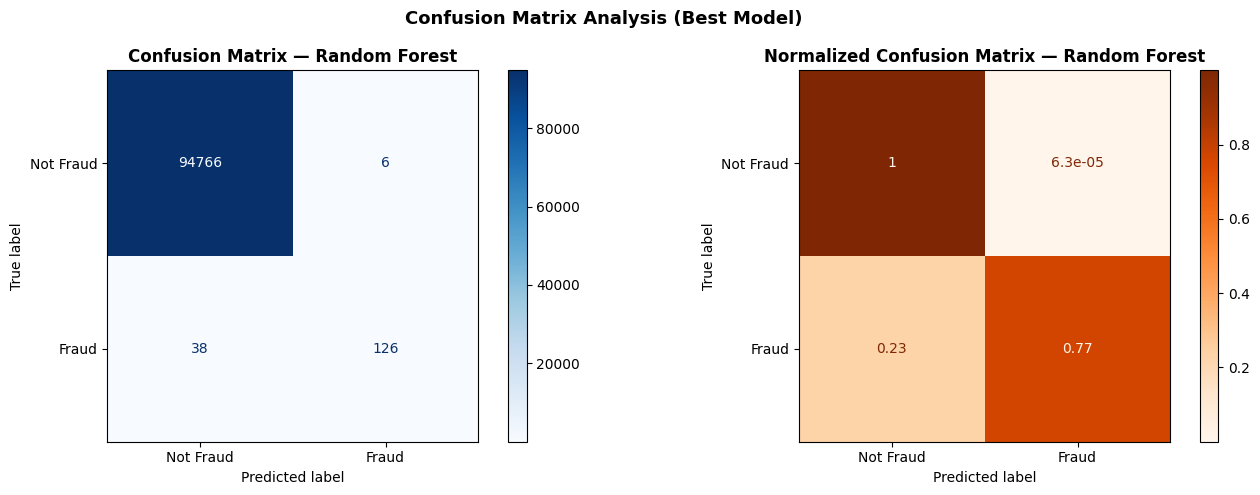

In [33]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=['Not Fraud', 'Fraud']
                       ).plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred_rf, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Not Fraud', 'Fraud']
                       ).plot(ax=axes[1], colorbar=True, cmap='Oranges')
axes[1].set_title('Normalized Confusion Matrix — Random Forest', fontweight='bold')

plt.suptitle('Confusion Matrix Analysis (Best Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [34]:
# Full Classification Report
print("Full Classification Report — Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
                             target_names=['Not Fraud', 'Fraud']))


Full Classification Report — Random Forest
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     94772
       Fraud       0.95      0.77      0.85       164

    accuracy                           1.00     94936
   macro avg       0.98      0.88      0.93     94936
weighted avg       1.00      1.00      1.00     94936



---
## Step 10 — Result Summary & Key Takeaways

### Model Performance
| Rank | Model | Accuracy |
|------|-------|----------|
| 🥇 1 | Random Forest | 99.95% |
| 🥈 2 | Linear Discriminant Analysis | 99.93% |
| 🥉 3 | Logistic Regression | 99.91% |
| 4 | Decision Tree | 99.91% |
| 5 | SVM | 99.83% |
| 6 | KNN | 99.83% |
| 7 | Naive Bayes | 99.28% |

### ⚠ The Accuracy Paradox
High accuracy on an imbalanced dataset is **misleading**.  
A model that classifies every transaction as "Not Fraud" would score **99.83%** — yet it would be completely useless.

**For fraud detection, Recall is the metric that matters most:**
> Recall = "Of all actual frauds, what % did we catch?"

A missed fraud (False Negative) is far more costly than a false alarm (False Positive).

### What's Next (Beyond This Course Baseline)
- **Handle class imbalance** → SMOTE oversampling, `class_weight='balanced'`
- **Threshold tuning** → Lower prediction threshold to boost Recall
- **Feature scaling** → StandardScaler on `Time` and `Amount` for SVM/KNN
- **Ensemble tuning** → Tune `n_estimators`, `max_depth` in Random Forest
- **Advanced models** → XGBoost, LightGBM, Isolation Forest (anomaly detection)


In [35]:
# Final Summary Print
print("=" * 60)
print("       CREDIT CARD FRAUD DETECTION — FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset     : 284,807 transactions | 492 fraud ({fraud_pct:.4f}%)")
print(f"Split       : 189,871 train | 94,936 test (stratified 2:1)")
print(f"Best Model  : Random Forest — {acc_rf}% Accuracy")
print(f"\nRandom Forest Confusion Matrix:")
print(f"  True  Negatives : {TN:,} (legit correctly identified)")
print(f"  True  Positives : {TP}    (fraud correctly caught)")
print(f"  False Positives : {FP}      (false alarms)")
print(f"  False Negatives : {FN}    (⚠ fraud MISSED)")
print(f"\n  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("\nProject Complete ✓")
print("=" * 60)


       CREDIT CARD FRAUD DETECTION — FINAL SUMMARY

Dataset     : 284,807 transactions | 492 fraud (0.1727%)
Split       : 189,871 train | 94,936 test (stratified 2:1)
Best Model  : Random Forest — 99.95% Accuracy

Random Forest Confusion Matrix:
  True  Negatives : 94,766 (legit correctly identified)
  True  Positives : 126    (fraud correctly caught)
  False Positives : 6      (false alarms)
  False Negatives : 38    (⚠ fraud MISSED)

  Precision : 95.45%
  Recall    : 76.83%
  F1-Score  : 85.14%

Project Complete ✓
